In [1]:
!pip install splink

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 kB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 23.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 23.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 673.9/673.9 kB 11.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [splink]2m5/6 [splink]]


In [64]:
!pip install spacy 
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 22.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.8/656.8 kB 4.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 844.4/844.4 kB 15.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 21.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [spacy]m15/16 [spacy]]

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<fro

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re as re
import thefuzz
import splink.comparison_library as cl
import spacy


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/envs/llj_revised/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/llj_revised/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/llj_revised/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.

In [2]:
from pathlib import Path
ROOT = Path().resolve().parent  # project root

In [ ]:
names = pd.read_csv(ROOT / 'data/raw/names.csv',
                    dtype={'case_row_id': str},
                    low_memory=False)

# drop
names = names[~names['case_row_id'].str.contains('#Docket Text', na=False)]

# now convert to int
names['case_row_id'] = names['case_row_id'].astype(int)
cases=pd.read_csv(ROOT / 'data/processed/cases/cases_cleaned_v3.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/matt/Desktop/Patent Litigation Analysis/data/processed/cases/cases_cleaned_v3.csv'

In [19]:
names['identifier'] = names['case_row_id'].map(cases.set_index('case_row_id')['identifier'])

In [16]:
print("names case_row_id sample:", names['case_row_id'].head())
print("cases case_row_id sample:", cases['case_row_id'].head())


names case_row_id sample: 0    1
1    3
2    4
3    5
4    6
Name: case_row_id, dtype: str
cases case_row_id sample: 0    33737.0
1    72268.0
2    83871.0
3    34070.0
4    52743.0
Name: case_row_id, dtype: str


In [2]:
names.to_csv(ROOT / 'data/processed/names/names_cleaned_v2.csv', index=False)

NameError: name 'names' is not defined

In [3]:
names=pd.read_csv(ROOT / 'data/processed/names/names_cleaned_v3.csv')

In [4]:
dupes = names.groupby(['party_type', 'name', 'identifier','name_long']).size().reset_index(name='count')
dupes = dupes[dupes['count'] > 1].sort_values('count', ascending=False)

print(f"Total duplicate groups: {len(dupes)}")
print(f"Total duplicate entries: {dupes['count'].sum()}")
print(dupes.head(20).to_string())

Total duplicate groups: 0
Total duplicate entries: 0
Empty DataFrame
Columns: [party_type, name, identifier, name_long, count]
Index: []


In [5]:
names.drop_duplicates(subset=['party_type', 'name', 'identifier'], keep='first', inplace=True)

# recalculate AFTER dropping
dupes = names.groupby(['party_type', 'name', 'identifier', 'name_long']).size().reset_index(name='count')
dupes = dupes[dupes['count'] > 1].sort_values('count', ascending=False)

print(f"Total duplicate groups: {len(dupes)}")
print(f"Total duplicate entries: {dupes['count'].sum()}")
print(dupes.head(20).to_string())

Total duplicate groups: 0
Total duplicate entries: 0
Empty DataFrame
Columns: [party_type, name, identifier, name_long, count]
Index: []


In [6]:
names['name'] = names['name'].str.replace(r'^[\-\.\&\s]+', '', regex=True)
# check for any remaining leading symbols
mask = names['name'].str.match(r'^[\-\.\&]', na=False)
print(names[mask]['name'].head(20))

Series([], Name: name, dtype: str)


In [7]:
print(f"Total unique names: {names['name'].nunique()}")

Total unique names: 175475


In [8]:
from thefuzz import fuzz

# get names that appear more than 100 times
name_counts = names['name'].value_counts()
high_freq_names = name_counts[name_counts >= 100].index.tolist()
print(f"Names appearing 100+ times: {len(high_freq_names)}")

# match only these
results = []

for i, name1 in enumerate(high_freq_names):
    for name2 in high_freq_names[i+1:]:
        score = fuzz.token_sort_ratio(name1, name2)
        if score >= 85:
            results.append({
                'name1': name1,
                'name2': name2, 
                'score': score,
                'count1': name_counts[name1],
                'count2': name_counts[name2]
            })

matches = pd.DataFrame(results).sort_values('score', ascending=False)
print(f"Potential matches found: {len(matches)}")
print(matches.to_string())

Names appearing 100+ times: 324
Potential matches found: 171
                                           name1                                        name2  score  count1  count2
0                                           Does                                         DOES    100    1484     381
1                                     Apple Inc.                                    Apple Inc    100    1116     544
2                                     Apple Inc.                                  Apple, Inc.    100    1116     228
3                                 Uniloc USA Inc                              Uniloc USA, Inc    100     600     209
4                                 Uniloc USA Inc                             Uniloc USA, Inc.    100     600     158
5                                    Pfizer Inc.                                 Pfizer, Inc.    100     595     376
6                        Hewlett-Packard Company                      HEWLETT PACKARD COMPANY    100     585     303
8  

In [9]:
#consolidation map
consolidation_map = {}

for _, row in matches[matches['score'] >= 97].iterrows():
    # keep the more frequent name as the canonical version
    if row['count1'] >= row['count2']:
        consolidation_map[row['name2']] = row['name1']
    else:
        consolidation_map[row['name1']] = row['name2']

print(f"Names to be consolidated: {len(consolidation_map)}")
print("\nConsolidation mapping:")
for old, new in consolidation_map.items():
    print(f"  '{old}' → '{new}'")

# apply 
names['name_consolidated'] = names['name'].map(consolidation_map).fillna(names['name'])

# verify
print(f"\nOriginal unique names: {names['name'].nunique()}")
print(f"Consolidated unique names: {names['name_consolidated'].nunique()}")

Names to be consolidated: 75

Consolidation mapping:
  'DOES' → 'Does'
  'Apple Inc' → 'Apple Inc.'
  'Apple, Inc.' → 'Apple Inc'
  'Uniloc USA, Inc' → 'Uniloc USA Inc'
  'Uniloc USA, Inc.' → 'Uniloc USA, Inc'
  'Pfizer, Inc.' → 'Pfizer Inc.'
  'HEWLETT PACKARD COMPANY' → 'Hewlett-Packard Company'
  'LG Electronics Inc' → 'LG Electronics, Inc.'
  'Samsung Electronics Co Ltd' → 'Samsung Electronics Co., Ltd.'
  'SAMSUNG ELECTRONICS CO., LTD.' → 'Samsung Electronics Co Ltd'
  'ArrivalStar S A' → 'ArrivalStar S.A.'
  'Dell Inc' → 'Dell Inc.'
  'Dell, Inc.' → 'Dell Inc'
  'SAMSUNG ELECTRONICS AMERICA, INC.' → 'Samsung Electronics America, Inc.'
  'Samsung Electronics America Inc' → 'SAMSUNG ELECTRONICS AMERICA, INC.'
  'Teva Pharmaceuticals USA Inc' → 'Teva Pharmaceuticals USA, Inc.'
  'TEVA PHARMACEUTICALS USA, INC.' → 'Teva Pharmaceuticals USA Inc'
  'Teva Pharmaceuticals USA Inc.' → 'TEVA PHARMACEUTICALS USA, INC.'
  'HTC AMERICA, INC.' → 'HTC America Inc'
  'Mylan Pharmaceuticals Inc.'

In [10]:
name_counts2 = names['name_consolidated'].value_counts()
high_freq_names = name_counts2[name_counts2 >= 100].index.tolist()
print(f"Names appearing 100+ times: {len(high_freq_names)}")

# match only these
results = []

for i, name1 in enumerate(high_freq_names):
    for name2 in high_freq_names[i+1:]:
        score = fuzz.token_sort_ratio(name1, name2)
        if score >= 85:
            results.append({
                'name1': name1,
                'name2': name2, 
                'score': score,
                'count1': name_counts[name1],
                'count2': name_counts[name2]
            })

matches = pd.DataFrame(results).sort_values('score', ascending=False)
print(f"Potential matches found: {len(matches)}")
print(matches.to_string())

Names appearing 100+ times: 264
Potential matches found: 64
                                     name1                                 name2  score  count1  count2
0                               Apple Inc.                             Apple Inc    100    1116     544
1        Samsung Electronics America, Inc.     SAMSUNG ELECTRONICS AMERICA, INC.    100     509     419
2            Samsung Electronics Co., Ltd.            Samsung Electronics Co Ltd    100     547     380
3           Teva Pharmaceuticals USA, Inc.          Teva Pharmaceuticals USA Inc    100     482     416
4           Teva Pharmaceuticals USA, Inc.        TEVA PHARMACEUTICALS USA, INC.    100     482     187
5                                Dell Inc.                              Dell Inc    100     528     315
11               MYLAN PHARMACEUTICALS INC           Mylan Pharmaceuticals, Inc.    100     406     305
8                           Uniloc USA Inc                       Uniloc USA, Inc    100     600     209
15  

In [ ]:
from thefuzz import fuzz

# Union-Find implementation
class UnionFind:
    def __init__(self):
        self.parent = {}
    
    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x, y):
        px, py = self.find(x), self.find(y)
        if px != py:
            self.parent[px] = py

uf = UnionFind()

# connect all pairs that score >= 97
for _, row in matches[matches['score'] >= 97].iterrows():
    uf.union(row['name1'], row['name2'])

# build consolidation map 
# canonical = the most frequent name in the group
consolidation_map = {}

# group all names by their root
from collections import defaultdict
groups = defaultdict(list)
for name in high_freq_names:
    root = uf.find(name)
    groups[root].append(name)

# for each group pick the most frequent name as canonical
for root, group_names in groups.items():
    if len(group_names) > 1:
        canonical = max(group_names, key=lambda x: name_counts[x])
        print(f"Group: {canonical}")
        for n in group_names:
            if n != canonical:
                print(f"   '{n}' → '{canonical}'")
                consolidation_map[n] = canonical





# apply
names['name_consolidated'] = names['name'].map(consolidation_map)

# verify
print(f"\nOriginal unique names: {names['name'].nunique()}")
print(f"Consolidated unique names (non-null): {names['name_consolidated'].nunique()}")
print(f"Rows consolidated: {names['name_consolidated'].notna().sum()}")
print(f"Rows left as NaN (to fill later): {names['name_consolidated'].isna().sum()}")

Group: Apple Inc.
   'Apple Inc' → 'Apple Inc.'
Group: Samsung Electronics America, Inc.
   'SAMSUNG ELECTRONICS AMERICA, INC.' → 'Samsung Electronics America, Inc.'
Group: Samsung Electronics Co., Ltd.
   'Samsung Electronics Co Ltd' → 'Samsung Electronics Co., Ltd.'
Group: Teva Pharmaceuticals USA, Inc.
   'Teva Pharmaceuticals USA Inc' → 'Teva Pharmaceuticals USA, Inc.'
   'TEVA PHARMACEUTICALS USA, INC.' → 'Teva Pharmaceuticals USA, Inc.'
Group: Dell Inc.
   'Dell Inc' → 'Dell Inc.'
Group: Uniloc USA Inc
   'Uniloc USA, Inc' → 'Uniloc USA Inc'
Group: MYLAN PHARMACEUTICALS INC
   'Mylan Pharmaceuticals, Inc.' → 'MYLAN PHARMACEUTICALS INC'
   'Mylan Pharmaceuticals Inc.' → 'MYLAN PHARMACEUTICALS INC'
Group: Amazon.com, Inc.
   'Amazon.Com, Inc.' → 'Amazon.com, Inc.'
Group: HTC America Inc
   'HTC AMERICA, INC.' → 'HTC America Inc'
Group: SANDOZ INC.
   'Sandoz, Inc.' → 'SANDOZ INC.'
Group: Google Inc.
   'Google, Inc.' → 'Google Inc.'
Group: Lupin Pharmaceuticals, Inc.
   'LUPIN PHAR

In [12]:
names['name_consolidated'] = names['name_consolidated'].fillna(names['name'])

names['name_consolidated'].value_counts().head(20)

name_consolidated
Apple Inc.                           1660
Does                                 1484
Teva Pharmaceuticals USA, Inc.       1085
MYLAN PHARMACEUTICALS INC             964
Samsung Electronics America, Inc.     928
Samsung Electronics Co., Ltd.         927
Dell Inc.                             843
David Folsom                          833
Uniloc USA Inc                        809
Microsoft Corporation                 792
Amazon.com, Inc.                      633
HTC America Inc                       625
Pfizer Inc.                           595
Hewlett-Packard Company               585
SANDOZ INC.                           579
LG Electronics, Inc.                  553
Google Inc.                           538
Uniloc Luxembourg S.A.                528
Melvino Technologies Limited          460
LG Electronics USA Inc                452
Name: count, dtype: int64

In [13]:
names['name'].value_counts()

name
Does                     1484
Apple Inc.               1116
David Folsom              833
Microsoft Corporation     792
Uniloc USA Inc            600
                         ... 
Eric Gannon                 1
Steven Merchant             1
Cary Butler                 1
Karen Coulter               1
DataNational, Inc.          1
Name: count, Length: 175475, dtype: int64

In [51]:
names=pd.read_csv(ROOT / 'data/processed/names/names_cleaned_v4.csv')

In [52]:
# strip leading symbols and whitespace
names['name_consolidated'] = names['name_consolidated'].str.replace(
    r'^[\-\.\&\s\,\:\;\"\']+', '', regex=True
)

# strip trailing whitespace and symbols
names['name_consolidated'] = names['name_consolidated'].str.replace(
    r'[\-\.\&\s\,\:\;\"\']+$', '', regex=True
)

# strip any remaining leading/trailing whitespace
names['name_consolidated'] = names['name_consolidated'].str.strip()

# verify
print("Sample after cleaning:")
print(names['name_consolidated'].head(20).tolist())

# check for any remaining leading symbols
remaining_mask = names['name_consolidated'].str.match(r'^[\-\.\&\,\:\;\"\']', na=False)
print(f"\nRemaining entries with leading symbols: {remaining_mask.sum()}")
print(names[remaining_mask]['name_consolidated'].head(20).tolist())

Sample after cleaning:
['Generix Drug Corp', 'U. S. COnstruction Manufacturing, Inc', 'On-Rite Hairpiece Company', 'R.L. Tuttle Jr', 'True Fit Chair Of Florida', 'Cry Chem International, Inc', 'Wang Laboratories Inc', 'Shelfco, Inc', 'Homer Products Intl., Inc', 'Automated Customs Systems, Inc', 'Lantech, Inc', 'Harris Watson Yachts, Inc', 'United States Sales Corporation', 'Robert Kraverath', 'Digital Products Corp', 'Robert Jennings', 'Adjustatrack Inc', 'Elexis Corp', 'Robert E. Leblanc', 'Royal Huisman Shipyard']

Remaining entries with leading symbols: 0
[]


In [53]:
#organizations classifier 



# 1. main regex
org_keywords = r'\b(inc|llc|llp|corp|ltd|co|company|corporation|incorporated|technologies|systems|group|holdings|enterprises|associates|partners|solutions|industries|international|pharmaceuticals|laboratories|university|institute|foundation|limited|plc|gmbh|sa|nv|bv|ag|pty|trust|bank|financial|capital|ventures|management|services|global|nationwide|national|federal|municipal|government|authority|department|ministry|bureau|agency|committee|commission|board|council|association|society|organization|organisation|network|alliance|coalition|consortium|cooperative|union|fund|investments|properties|realty|construction|engineering|manufacturing|medical|health|pharma|biotech|bio|tech|digital|media|communications|telecom|energy|power|electric|oil|gas|chemical|research|analytics|consulting|advisors|law|legal|attorneys|advocates|s\.a|s\.p\.a|s\.a\.s|k\.k|s\.r\.l|a\.g|b\.v|n\.v|p\.l\.c|oy|ab|as|srl|spa|kk|lc|n\.a|l\.l\.c|usa|lp|l\.p|s\s+a|n\s+v|b\s+v|s\/a|n\/v|b\/v|s\.a\.s|s\/a\/s)\b'
names['entity_type'] = names['name_consolidated'].str.contains(
    org_keywords, case=False, regex=True, na=False
).map({True: 'Organization', False: 'Individual'})

# 2. slash/space pattern
slash_space_pattern = r'\b(s[\s\/\.]a|n[\s\/\.]v|b[\s\/\.]v|s[\s\/\.]a[\s\/\.]s|s[\s\/\.]p[\s\/\.]a|s[\s\/\.]r[\s\/\.]l|k[\s\/\.]k|p[\s\/\.]l[\s\/\.]c|l[\s\/\.]l[\s\/\.]c|l[\s\/\.]p|n[\s\/\.]a|a[\s\/\.]g|c[\s\/\.]v|s[\s\/\.]de[\s\/\.]c[\s\/\.]v)\b'
slash_mask = names['name_consolidated'].str.contains(
    slash_space_pattern, case=False, regex=True, na=False
)
names.loc[slash_mask, 'entity_type'] = 'Organization'

# 3. organizational indicator words unlikely to appear in individual names
org_indicator_pattern = r'\b(system|systems|technology|technologies|wireless|provider|providers|partnership|partnerships|software|hardware|semiconductor|network|networks|device|devices|solution|solutions|product|products|equipment|instruments|diagnostics|therapeutics|sciences|dynamics|analytics|robotics|aerospace|defense|security|optical|photonics|imaging|electronics|electrical|mechanical|industrial|automotive|aviation|maritime|logistics|transport|distribution|retail|commerce|payment|payments|processing|platform|platforms|cloud|storage|computing|ventures|venture|equity|asset|assets|acquisition|acquisitions|intellectual|licensing|license|patent|patents|trademark|trademarks|fabrication|polymer|plastics|composite|materials|chemicals|petroleum|refining|mining|extraction|semiconductor|supplies|supply|dealer|dealership|studio|studios|publishing|publisher|records|entertainment|productions|production|broadcasting|broadcast|wireless|satellite|fiber|infrastructure|development|developer|developers|healthcare)\b'

org_indicator_mask = names['name_consolidated'].str.contains(
    org_indicator_pattern, case=False, regex=True, na=False
)
names.loc[org_indicator_mask, 'entity_type'] = 'Organization'
print(f"Additional organizations caught by indicator words: {org_indicator_mask.sum()}")

# 4. numbers 

number_mask = (
    (names['entity_type'] == 'Individual') &
    (names['name_consolidated'].str.contains(r'\d', na=False))
)
names.loc[number_mask, 'entity_type'] = 'Organization'

# 5. retail pattern 
retail_pattern = r'\b(store|stores|shop|shops|market|markets|mart|plaza|center|centre|outlet|boutique|dealer|dealership|clinic|hospital|hotel|resort|restaurant|cafe|bar|gym|salon|spa|studio|gallery|museum|theater|theatre|pharmacy|dispensary|laboratory|labs|lab|warehouse|depot|supply|supplies|hardware|furniture|flooring|roofing|plumbing|electrical|mechanical|automotive|dealership|leasing|rental|rentals|realty|mortgage|insurance|accounting|staffing|staffing|recruiting|staffing|cleaning|landscaping|catering|printing|packaging|shipping|freight|courier|trucking|hauling|moving|storage|wholesalers|wholesaler)\b'

retail_mask = (
    (names['entity_type'] == 'Individual') &
    (names['name_consolidated'].str.contains(retail_pattern, case=False, regex=True, na=False))
)
names.loc[retail_mask, 'entity_type'] = 'Organization'

# 6. last word geographic/america rules
last_word_orgs = ['america', 'japan', 'korea', 'europe', 'asia', 'worldwide', 'global']
last_word_mask = names['name_consolidated'].str.strip().str.split().str[-1].str.lower().isin(last_word_orgs)
names.loc[last_word_mask, 'entity_type'] = 'Organization'

print(names['entity_type'].value_counts())
print("\nSample Individuals:")
print(names[names['entity_type'] == 'Individual']['name_consolidated'].sample(30).tolist())

/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_47474/3370198912.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  names['entity_type'] = names['name_consolidated'].str.contains(
/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_47474/3370198912.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  slash_mask = names['name_consolidated'].str.contains(
/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_47474/3370198912.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  org_indicator_mask = names['name_consolidated'].str.contains(


Additional organizations caught by indicator words: 104482


/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_47474/3370198912.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (names['name_consolidated'].str.contains(retail_pattern, case=False, regex=True, na=False))


entity_type
Organization    483256
Individual       76763
Name: count, dtype: int64

Sample Individuals:
['Robert Hartmann', 'joypockets', 'Alexander Segal', 'Gary Endres', 'Rene Brillembourg', 'ROBERT A. BEASON', 'William Hone', 'Adnan Shennib', 'Revol', 'Orville H. Holz, Jr', 'Doe Defendants', 'Velvet Publications', 'Leon Green', 'TCI of Springfield', 'AKTIEBOLAGET HASSLE', 'Does', 'Eugene G. Charette', 'GRAZIELLA GIORDINI', 'ASO Thomas S Kidde', 'Does', 'Fournier Industrie et Sante', 'MARTIN PROFESSIONAL', 'David Folsom', 'Martin Philip Hull', 'MTU Aero Engines', 'Eric A. Klein', 'Richard Louis Vitacco', 'Joseph Anella, Jr', 'DEBASISH MUKHOPADHYAY', 'Jeff Lion']


In [81]:
#procedural classifier 
procedural_pattern = r'^(Special Master|John Doe|John Does|Does|Technical Advisor|Liaison Counsel|ENE Evaluator|ADR Panel|MDL Panel|Facilitating Mediator|Facilitative Mediator|Attorney Settlement Officer|Voluntary Dispute Resolution Neutral|Unidentified Part|Unknown Part|Unknown Parties|Unknown Party|All Defendants|All Plaintiffs|All Parties|Pro Se Party|Sealed Defendant|Incorrectly Filed|Counter Defendant|Interested Attorney|Service List|Clerk of MDL Panel|United States of America|Or Specific)\b'
procedural_mask = names['name_consolidated'].str.match(
    procedural_pattern, case=False, na=False
)

# catch "1-10 John Does", "1-100 John Does" - number first
number_john_does_mask = names['name_consolidated'].str.match(
    r'^\d+[\-\–\s]+\d*\s*John\s+Does?', case=False, na=False
)

# catch "John Does 1-10", "John Does 1-100" - number at end
john_does_number_mask = names['name_consolidated'].str.match(
    r'^John\s+Does?\s+[\dIVXivx\-\–]+', case=False, na=False
)

# catch "Does 1-8", "Does 1-100" - does then number
does_number_mask = names['name_consolidated'].str.match(
    r'^Does?\s+[\dIVXivx\-\–]+', case=False, na=False
)

# catch "1-10" standalone or similar pure number ranges
number_range_mask = names['name_consolidated'].str.match(
    r'^\d+[\-\–]\d+$', na=False
)

# catch "John 1-10 Does", "John 1-100 Does" etc
john_numbered_mask = names['name_consolidated'].str.match(
    r'^John[\s]+[\d\-IVXivx]+[\s]+Does', case=False, na=False
)

# catch pure number strings
numbers_only_mask = names['name_consolidated'].str.match(r'^\d+$', na=False)

# catch "all defendants" with leading/trailing symbols only
all_defendants_mask = names['name_consolidated'].str.match(
    r'^[\-\.\&\s]*all\s+defendants[\-\.\&\s]*$', case=False, na=False
)

#a place corp 
place_entity_mask = names['name_consolidated'].str.match(
    r'^a\s+(delaware|california|nevada|texas|florida|new\s+york|new\s+jersey|ohio|illinois|georgia|michigan|washington|virginia|massachusetts|pennsylvania|maryland|colorado|arizona|indiana|tennessee|north\s+carolina|south\s+carolina|minnesota|wisconsin|connecticut|oregon|utah|louisiana|alabama|kentucky|iowa|kansas|missouri|arkansas|mississippi|oklahoma|foreign|domestic)\s+(corp|corporation|company|limited\s+partnership|limited\s+liability|llc|llp|lp|partnership|incorporated|inc|co\.?)\b',
    case=False, na=False
)
#chien luen
chien_luen_mask = names['name_consolidated'].str.match(r'^\(CHIEN LUEN', case=False, na=False)



does_mask = names['name_consolidated'].str.match(r'^Does\b', case=False, na=False)

combined_procedural = (
    procedural_mask |
    does_mask |
    does_numbered_mask |
    john_numbered_mask |
    number_john_does_mask |
    john_does_number_mask |
    does_number_mask |
    number_range_mask |
    numbers_only_mask |
    all_defendants_mask |
    place_entity_mask |
    chien_luen_mask
)


names.loc[combined_procedural, 'entity_type'] = 'Procedural'

print(f"Procedural entries classified: {combined_procedural.sum()}")
print(names['entity_type'].value_counts())

Procedural entries classified: 5792
entity_type
Organization    490110
Individual       64086
Procedural        5823
Name: count, dtype: int64


In [82]:
# identify single word names only among those still classified as Individual
single_word_mask = (
    (names['entity_type'] == 'Individual') & 
    (names['name_consolidated'].str.strip().str.split().str.len() == 1)
)

single_word_names = names[single_word_mask]['name_consolidated'].value_counts()

print(f"Total single word individuals: {single_word_mask.sum()}")
print(f"Total unique single word individual names: {len(single_word_names)}")
print("\nTop 50:")
print(single_word_names.head(1000).to_string())

Total single word individuals: 0
Total unique single word individual names: 0

Top 50:
Series([], )


In [83]:
# reclassify single word individuals as Organization except Does variants
does_variants = ['does', 'doe', 'unknown', 'anonymous', 'defendants', 
                 'plaintiffs', 'intervenors', 'counterdefendants']


single_word_mask = (
    (names['entity_type'] == 'Individual') & 
    (names['name_consolidated'].str.strip().str.split().str.len() == 1)
)
does_mask = names['name_consolidated'].str.lower().str.strip().isin(does_variants)
names.loc[single_word_mask & does_mask, 'entity_type'] = 'Procedural'

# reclassify single words 
names.loc[single_word_mask & ~does_mask, 'entity_type'] = 'Organization'

# give Does variants their own category
names.loc[single_word_mask & does_mask, 'entity_type'] = 'Procedural'

print(names['entity_type'].value_counts())

entity_type
Organization    490110
Individual       64086
Procedural        5823
Name: count, dtype: int64


In [86]:
certain_organizations = {
    "Aktiebolaget Hassle", "AKTIEBOLAGET HASSLE", "Akteibolaget Hassle", "Ktiebolaget Hassle",
    "Johnson & Johnson", "JOHNSON & JOHNSON",
    "Fifth Third Bancorp",
    "NOVO NORDISK A/S",
    "CEPHALON FRANCE", "Cephalon France",
    "Samsung Telecommunications America LLP",
    "President and Fellows of Harvard College",
    "CitiBank NA", "Citibank NA", "Citibank (South Dakota) NA", "Citibank (West), F.S.B.", "Citibank, F.S.B.",
    "Fournier Industrie et Sante'", "FOURNIER INDUSTRIE ET SANTE",
    "Morgan Stanley",
    "CANTOR COLBURN LLP",
    "Novozymes A/S",
    "British Telecommunications",
    "Synthon S.R.O.",
    "BMG Music",
    "Coloplast A/S",
    "Axis-Shield ASA",
    "Fish & Richardson P.C.", "Fish & Richardson PC", "Fish & Richardson", "Fish & Richardson, PC",
    "GN Resound A/S",
    "Norton-Alcoa Proppants",
    "UCB Societe Anonyme",
    "Merck & Cie", "Merck & CIE",
    "DaimlerChrysler, A. G.",
    "WolfBlock LLP",
    "NYSE Euronext",
    "LES LABORATOIRES SERVIER",
    "Johnson Controls Interiors L. L. C.",
    "BASF Aktiengesellschaft", "BASF AKTIENGESELLSCHAFT", "BASF SE",
    "GN Netcom A/S",
    "BMW North America L. L. C.",
    "Freitas Angell & Weinberg LLP",
    "Shore*Deary, LLP",
    "Paragon Sporting Goods",
    "Bravo Sports",
    "ROSENMAN & COLIN LLP",
    "Aircraft Technical Publishers",
    "Air Canada",
    "Martin Professional A/S",
    "Oticon A/S",
    "Lippert Components",
    "PPS Data",
    "Cathay General Bancorp",
    "Siemens Aktiengesellschaft",
    "Sybron Dental Specialities",
    "JetBlue Airways Coporation",
    "Seirus Innovative Accessories",
    "Foley & Lardner LLP",
    "AL-CORN CLEAN FUEL",
    "Stiftung Fur Diagnostiche Forschung",
    "Ivoclar Vivadent",
    "Finnegan, Henderson, Farabow, Garrett & Dunner, LLP",
    "Atmel France",
    "Mallinckrodt IP",
    "Infinity Headwear & Apparel",
    "metacluster lt, UAB", "UAB Metacluster LT",
    "Green Valley Bancorp, Mhc", "Green Valley Bancorp Mhc",
    "Hewlett Packard",
    "Bed, Bath & Beyond", "Bed Bath & Beyond",
    "Morrison & Foerster LLP",
    "Applied Biosystems", "PE Applied Biosystems Division",
    "Ion Beam Applications, S. A.",
    "Tama Plastic Industry",
    "Asetek, A/S",
    "McDermott Will & Emery LLP",
    "Bard Peripheral Vascular",
    "SAP SE",
    "Niro, Scavone, Haller & Niro",
    "Danisco A/S",
    "Pfizer Ireland Pharmaceutials",
    "Asus Computer Intl", "Asustek Computer",
    "Time Warner Cable",
    "TDF SAS",
    "Sam's Club",
    "Gillet Outillage",
    "Dodge & Cox",
    "Lego A/S",
    "Baylor College of Medicine",
    "Oakley Direct",
    "DSM Dyneema",
    "Breckenridge Pharmaceutical",
    "Niro A/S", "NIRO A/S",
    "The New York Mercantile Exchange",
    "Belkin Components",
    "MAX-PLANCK-GESELLSCHAFT ZUR FORDERUNG DER WISSENSCHAFTEN E.V.",
    "Hiscock & Barclay, LLP",
    "BATH SAVINGS INSTITUTION",
    "SMIC, Americas",
    "Walt Disney Pictures and Television",
    "Lenovo (United States)",
    "Provo Craft and Novelty",
    "Crabtree & Evelyn",
    "OSRAM Gesellschaft mit beschrankter Haftung",
    "Worrel & Worrel",
    "Kickstarter, PBC",
    "SITO Mobile R&D IP",
    "Pacific Coast Lighting",
    "Boston Scientific Scimed",
    "Western Minerals",
    "Saint-Gobain Glass France",
    "Glud & Marstrand A/S",
    "Manwin Holding SARL",
    "MSI Computer",
    "General Atomics",
    "nVidia Corpation",
    "Unaxis Balzers Aktiengesellschaft",
    "AAA Wire Rope and Splicing",
    "Bell's Precision Grinding",
    "Nature's Finest Candles",
    "Custom Accessories",
    "Swiss Post",
    "Wells Lamont",
    "Cornell Iron Works",
    "Allstate Texas Lloyd's",
    "Speedway Motors",
    "Medtronic Vascular",
    "Stryker Orthopaedics",
    "Rontan Eletro Metalurgical LTDA",
    "RPM Optoelectronics",
    "W.C. HERAEUS GMBG",
    "Stichting Voor de Technische Wetenschappen",
    "Wenger NA",
    "Nagra France SAS",
    "Pacific Bell",
    "IBM IBM",
    "Bell Mold Components",
    "Western Metal Lath",
    "MED-EL Elektromedizinische Gerate Ges.m.b.H.",
    "Volkswagen Aktiengesellschaft",
    "Hasselblad A/S",
    "Drucker & Genuth, MDS, P.C.",
    "Gambro A.B.",
    "E.R. Squibb & Sons",
    "Loretel Cablevision",
    "United Van Lines",
    "Kendall Med-West",
    "Radio Shack",
    "Utah Pacific Brine Shrimp Eggs",
    "Red Ball Welding",
    "United States Chess Federation",
    "ARI Flow Control Accessories",
    "Jenkens & Gilchrist",
    "PATTERSON BELKNAP WEBB & TYLER, LLP",
    "Massachusetts Eye And Ear Infirmary",
    "MAC Tools",
    "Eastman Kodak Comp.",
    "Burlington Coat Factory",
    "Fish & Richardson PC",
    "Intel Corporaton",
    "Orrick, Herrington & Sutcliffe LLP",
    "Indusparquet Industria e Comercio de Madeiras Ltda.",
    "WAGO Verwaltungsgesellschaft mbH",
    "Sony Kabushiki Kaisha", "Sony Kabushiki Kaisha ",
    "DAS Distributors",
    "Osmotica Kereskedelmi Es Szolgaltato KFT",
    "Procter & Gamble",
    "ECCO Sko A/S",
    "KNAUF INSULATION SPRL",
    "Johns Manville",
    "Cemix Holding, A. G.",
    "Great Western Termite Control",
    "Nature's Way Pest Control",
    "Patmont Motor Werks",
    "VISX Incorporation",
    "SMITHKLINE BEECHAM",
    "TelCan Incorporation",
    "Grim Reaper Broadheads",
    "Bear Factory, L. L. C.",
    "Sun Optics",
    "Sheward & Son & Sons",
    "Citibank (West), F.S.B.", "Citibank, F.S.B.",
    "RBS Citizens, NA",
    "Sung's Home Collection",
    "Shea Homes",
    "GE Lighting",
    "Sun Mountain Sports",
    "Royal Philips",
    "Colonial Savings, F.A.",
    "NexBank, SSB",
    "MidSouth Bancorp",
    "TRUSTEES OF TUFTS COLLEGE",
    "Nuvo Colours",
    "Globe Motors",
    "Skadden Arps Slate Meagher & Flom LLP",
    "PLIVA-LACHEMA A.S.",
    "Falcon Telecable",
    "AT&T Mobility",
    "Minnesota, State of",
    "City of Lincoln",
    "Linkedin Corporated",
    "Topcon Tierra",
    "Rapid EPS South",
    "Shook Hardy & Bacon",
    "Stubbs, Alderton & Markiles, LLP",
    "Southern Visions, LLP",
    "Kamstrup A/S",
    "CONTENT SQUARE SAS",
    "Allergan Industrie SAS",
    "MB&A Robotways",
    "oxysales, UAB",
    "Carnegie Institution of Washington ",
    "United States Postal Service",
    "US Court of Appeals",
    "Plastiques Cellulaires Polyform",
    "UNM Rainforest Innovations",
    "Larson Archery",
    "Paragon Luggage",
    "Discus Dental",
    "Tinkers & Chance",
    "Garteiser Honea",
    "Banner Mountain Sprouts",
    "Fascinations Toys & Gifts",
    "APS Nutrition",
    "Star Video Duplicating",
    "Sonic Innovations",
    "Vital Bow Gear",
    "Corbett Life Science",
    "Handstands Promo",
    "Genesearch, L. L. C.",
    "Stroock & Stroock & Lavan",
    "Acon Labortories, In",
    "ABC Companies", "ABC COMPANIES",
    "XYZ Corporations",
    "Aziende Chimiche Riunite Angelini Francesco ACRAFSpA",
    "American Infertility of New York, P.C.",
    "SUPPLEMENT CENTRAL",
    "LL&L Innovations",
    "Omni Block",
    "TTR HP",
    "DMX, L. L. C.",
    "Kohus-Timperman Part",
    "DBA Puracap Caribe",
    "Ashby & Geddes PA",
    "Red Star Traders",
    "JC Penney","Aker BioMarine ASA",
    "Land Rover",
    "Amer Sports Winter & Outdoor",
    "BOKF NA", "BOKF, NA",
    "Jay Franco & Sons",
    "Del Mar Avionics",
    "Packard Bell NEC",
    "General Motors",
    "Reno A&E",
    "RICK'S AUTO REPAIR",
    "Flagstar Bancorp",
    "United SGP",
    "Breast Cancer Action",
    "SYNTHON S.R.O. BLANSKO",
    "Dodge & Cox Funds",
    "ABC Corporations",
    "Time Warner",
    "SMIC Americas",
    "Formutech Nutrition",
    "Intermountain Rigging and Heavy Haul",
    "ConAgra Foods",
    "Kinsel Ford",
    "Sioux Steel",
    "Hardesty & Hanover LLP",
    "Societe Technique De Pulverisation",
    "AudioFAX IP LLP",
    "Ground Zero Design",
    "Syngenta Biotechnology",
    "Kathrein-Werke KG.",
    "The President and Fellows of Harvard College",
    "Acuity Brands",
    "EK Ekcessories",
    "Invista North America Sarl",
    "Bayer Cropscience Aktiengesellschaft",
    "Illinois Valley Cellular",
    "ArcelorMittal France",
    "Fitch, Even, Tabin & Flannery LLP",
    "Millipore SAS",
    "HISCOCK & BARCLAY, LLP",
    "Hill, Kertscher & Wharton, LLP",
    "Continental Cablevision of Richmond",
    "Universal Pictures",
    "AMERICAN PHARMACEUTICAL",
    "PACIFIC BELL",
    "FOURNIER INDUSTRIE ET SANTE'",
    "Trustees of Dartmouth College",
    "DBA Amtrak",
    "Hilton Hotels Coroporation",
    "Michilin Prosperity",
    "ButterCup Legacy",
    "AccessBank Texas",
    "JWC Environmental",
    "Sanford Institution for Savings",
    "MERCK & CIE",
    "Business Objects Americas",
    "Mercedes-Benz of Plano",
    "Tama Plastic  Industry",
    "Emerald Coast Flyboard",
    "Spalding & Evenflo C",
    "Pepinieres Et Vergers Escande, SCEA",
    "Sherwood-Davis & Geck",
    "Euro United Corporated",
    "FMS House",
    "Groz-Beckert KG",
    "Rossignol Ski",
    "Interpool Pool Cover Team",
    "Mercury Marine",
    "Koko's Confectionery & Novelty",
    "Tandberg ASA",
    "Cane Creek Cycling Components",
    "Laundry Loops",
    "Avenue Innovations",
    "BOEHRINGER INGELHEIM",
    "WINDMOLLER & HOLSCHER KG",
    "BK Jewellery",
    "Ernst & Young LLP",
    "Societe Air France",
    "DPS NUTRITION",
    "Baltimore Therapeuti",
    "Coastal Nursery",
    "S & B Filters",
    "Eastman Outdoors",
    "Delphi, L. L. C.",
    "Argento SC By Sicura",
    "Surface Combustion",
    "Hoehn Motors",
    "Kurgan & Cheviot",
    "Fantom Optics",
    "Rowe Fenestration",
    "Shaw & Sons",
    "Dots of Fun",
    "White Pine",
    "Herrington - The Enthusiasts'",
    "Telefonaktiebolaget LM Ericsson", "Telefonaktiebolaget LM Ericcson",
    "H. LUNDBECK A/S",
    "CITY OF HOPE", "City of Hope",
    "U.S. Bancorp", "US Bancorp",
    "Astra Aktiebolag", "ASTRA AKTIEBOLAG",
    "GODECKE AKTIENGESELLSCHAFT",
    "SCR Pharmatop", "SCR PHARMATOP",
    "JANSSEN R&D IRELAND",
    "Life Fitness",
    "United States",
    "Zions Bancorporation",
    "MERIAL SAS",
    "Disney Online",
    "Accenture LLP",
    "Cellectis bioresearch",
    "MERCK KGAA",
    "Industrias Auxiliares Faus S.L.",
    "PLIVA HRVATSKA D.O.O.", "PLIVA-HRVATSKA d.o.o.", "PLIVA d.d.", "PLIVA D.D.",
    "The Stanley Works",
    "Widex A/S",
    "Illinois Tool Works",
    "Catheter Connections",
    "Baylor College Of Medicine",
    "State of California", "California, State of",
    "Santa's Best",
    "Music Choice",
    "United States of America, Ex. Rel.",
    "Reliable Knitting Works",
    "Ossur HF", "Ossur hf",
    "High Point Sarl",
    "Sanofi Mature IP  ",
    "Toys R Us", "Toys 'R Us",
    "Harmony Farms",
    "QR Spex",
    "The Pep Boys-Manny, Moe & Jack", "The Pep Boys - Manny, Moe & Jack",
    "Pep Boys Manny Moe & Jack of California", "Pep Boys - Manny Moe & Jack",
    "Commissariat A L'Energie Atomique",
    "XYZ Companies",
    "A/S Niro Atomizer",
    "Planet Bingo",
    "Danfoss Drives A/S", "Danfoss A/S",
    "J.A.W. Brine Shrimping",
    "Cedar Fair",
    "Maui County",
    "Hawaiian Gardens Casino",
    "SFI of Tennessee",
    "Elite Lighting",
    "Wine Master Cellars LLLP",
    "MUSTAFA NEVZAT ILAC SANAYII A.S.",
    "Bragg Companies",
    "Atmel SARL",
    "Lonely Planet",
    "Institut Pasteur", "INSTITUT PASTEUR",
    "Free Motion Fitness",
    "Iron Grip Barbell", "Iron Grip Barbell, -",
    "High Speed Video",
    "Automated Merchandis",
    "OOO Acronis",
    "Babyliss Faco Sprl", "Babyliss Faco SPRL",
    "Automated Business Companies",
    "Big Lots",
    "City of Visalia",
    "DISTRICT OF COLUMBIA",
    "City of Memphis",
    "Hollywood Tans",
    "World Link Companies",
    "Magma Design Automation",
    "Panther Vision",
    "Excitor A/S",
    "Classic Chevrolet Beaumont",
    "Electronic Arts",
    "Tabletops Unlimited",
    "King Of The Road",
    "Gator Tail",
    "Tommyco Kneepads",
    "Wargamingnet LLP",
    "Oak Grove Memorial Gardens",
    "Marposs Societa Per Azioni",
    "Samsung Telecommunications LLP",
    "Estes Express Lines",
    "State of New York",
    "Farmaceutisk Laboratorium Ferring A/S",
    "Falcon Cablevision",
    "Sunrise Farms",
    "Circuit City",
    "Venable LLP",
    "Aktiebolaget Draco",
    "CITY OF HOBOKEN",
    "L' Universite Montpellier II",
    "City of Crystal Lake",
    "Jay At Play",
    "Jones Day",
    "Schneider Automation",
    "Hicks Park LLP",
    "Mud Buddy",
    "Aliphcom d/b/a Jawbone",
    "LOGOPAINT A/S",
    "Manufacture D'Articles De Precision A Et De Dessin",
    "Opus Distributing",
    "Marix Distributing",
    "PureCircle Sdn Bhd",
    "Escalade Sports",
    "Fisher-Price Toys",
    "BECTON DICKINSON",
    "Mirror Lite of North Carolina",
    "City of Chicago, The",
    "Hardcore Composites",
    "Can You Imagine",
    "Duane Morris LLP",
    "Greenberg Traurig LLP",
    "Goathead Saloon-AAA ATMS",
    "Elite Outdoors",
    "Spectrum DNA",
    "Vikimatic of Ohio",
    "California Spas",
    "OPW FUELING COMPONENTS", "OPW Fueling Components",
    "Esselte Americas",
    "Medco Tool",
    "Clinical Innovations",
    "Rug Doctor",
    "Fresh Concepts",
    "Visual Concepts",
    "Cable Car Sunglasses",
    "Texas Heat Pack",
    "Genmark Automation",
    "City of San Antonio",
    "IPtronics A/S",
    "Fitness Unlimited",
    "Just Intellectuals, PLLC",
    "Robe Lighting S.R.O.",
    "COMFORT REVOLUTION",
    "Stampin' Up!",
    "Acorn Bay",
    "Park Rapids, City of",
    "MAINE FROZEN FOODS",
    "Brooklyn, City of",
    "Terex Princeton",
    "Little Things Mean A Lot",
    "Custom Cowboy Creations",
    "Honeybaked Ham",
    "City of Atlanta",
    "Perkins Coie LLP",
    "Garber Farms",
    "Noble Biomaterials",
    "Gun Rifle Gear",
    "City of Yonkers",
    "State of Hawaii",
    "WORLD CLASS NUTRITION",
    "LOCKOUT SUPPLEMENTS",
    "Small Cell Innovations",
    "Controversy Music",
    "Osteometer Meditech A/S",
    "Player Wire Wheels",
    "Everything for Love",
    "Arch of West Virginia",
    "Urban Biologics",
    "Silver Sage",
    "ADD (Amazing Deals & Discounts)",
    "Action Target",
    "MARIN CATHOLIC HIGH SCHOOL",
    "AOC Int'l",
    "Window Wells",
    "Bioworld Merchandising",
    "My First Shades",
    "Hot Topic Merchandising",
    "Osram Sylvania",
    "High Country Concepts",
    "Love-Less Ash",
    "Won Door",
    "Gene by Gene",
    "Water Out Oregon",
    "Kvaerner A.S.",
    "Cable Car Eyeware",
    "Da Kine Hawaii",
    "The Sharper Image",
    "Diamond ID",
    "Colorado Seminary",
    "Channel Islands Sawing",
    "Handsome Rewards",
    "Taza Design",
    "American Fireglass",
    "Class One Orthodontics",
    "Structural Panels",
    "Signature Marketing",
    "West Coast Aesthetics",
    "Mount Spelman P.C.",
    "TAYLOR WISEMAN & TAYLOR",
    "High Country Archery",
    "Perennials Plus",
    "Seasons Condominiums",
    "American Covers",
    "Bayard, P.A.",
    "MALLINCKRODT IP",
    "VND Butyrate",
    "New Delphi",
    "New Dane",
    "SUPPLEMENT CENTRAL",
    "Dots of Fun",
    "Ladas & Parry LLP",
    "Stenbock & Everson",
    "Bruggeman & Desouter",
    "United States Attorney's Office Northern District of California",
    "McManemin Companies",
    "Serviform, S.L.R.",
    "JF Microtechnology SDN BHD",
    "SteelSeries ApS",
    "Inspire Fitness and Sunset Swings",
    "Mitsui Petrochem Ind",
    "Nissho Iwai American",
    "Stewart & Stevenson",
    "Willson Safety Prodcts Division",
    "First Team Sports",
    "Patco Wyoming", "Patco Companies", "Patco Oklahoma",
    "Fisher & Amzel",
    "H & M Sales",
    "Biomedical Polymers",
    "Pharmacia & Upjohn",
    "BeverageAir Division",
    "Conley Rose & Taylor PC",
    "McClanahan & Clearman, LLP",
    "Vista Dental",
    "Newdale School",
    "Mineracao Curimbaba LTDA",
    "BD Diesel Performance",
    "Asia Pacific Latex Sdn. Bhd.",
    "YTY Industry Sdn. Bhd.", "YTY Industry (Manjung) Sdn. Bhd.",
    "Green Prospect Sdn. Bhd.",
    "Glovco Holding Sdn. Bhd.",
    "PT Maja Agung Latexindo",
    "Beijing Latex Factory",
    "Hartalega Sdn. Bhd.",
    "Beijing Huateng Rubber Plastic",
    "Riverstone Resources Sdn. Bhd.",
    "SAP Aktiengesellschaft",
    "Cameron Balloons",
    "Herrington's Catalog",
    "Mintex Corporatiion",
    "Durablue Mfg.",
    "Vetgen, L. L. C.",
    "GTCO Calcomp, Incoporated",
    "LA Weight Loss",
    "Alcatel Lucent",
    "Murray & Murray, PC",
    "Wilson Sonsini Goodrich & Rosati, P.C.",
    "Kleiner Perkins Caufield & Byers",
    "Kootenai County Public Defenders Office",
    "State Appeallate Pubic Defender's Office",
    "Kootenai County Prosecutor's Office",
    "PLIVA-Hrvatska d.o.o.",
    "Quinn Emanuel Urquhart & Sullivan LLP",
    "Wilson Sporting Good",
    "Norton Alcoa Proppants",
    "Rieter Ingolstadt Spinnereimaschinenbau Aktiengesellschaft",
    "The Gleason Works",
    "Pelican Accessories",
    "Alexa Internet",
    "Oce Better Business Machines",
    "VCA Pictures",
    "Hustler Video",
    "Kingspan Insulated Panels",
    "Kunshan Macauto",
    "Blue Calypso",
    "Wedbush Futures (d/b/a www.efutures.com)",
    "Wedbush Futures (d/b/a wedbushfutures.com)",
    "Trade FX Futures (d/b/a tradefxfutures.com)",
    "Princo Croporation",
    "Promo Wear",
    "Cooper & Dunham LLP",
    "Grupo Cementos De Chihuahua",
    "Centennial Molding",
    "American Arium",
    "Contour Fabricators",
    "Polar Electro",
    "Oregon Scientific",
    "WW Distributors",
    "General Nutrition Centers",
    "Chaser Aerodynamics",
    "Ciena Coporation",
    "Scent-Sation LA",
    "Burns Morris Stewart",
    "Mayback & Hoffman, PA",
    "Continental Credit",
    "Leaps & Rebounds",
    "Societe Industrielle De Matieres Plastiques",
    "Retrospection Marketing",
    "SMIC, Americas ", "SMIC, Americas",
    "Blue Cross and Blue Shield of Texas",
    "Natural Cut SAS",
    "DEPUY SYNTHES COMPANIES",
    "SME Steel Contractors",
    "UNIVERSITEIT GENT",
    "Pacific Ethanol Stockton",
    "Volkswagen Credit",
    "Ramey & Schwaller, LLP",
    "ITW Polymers & Fluids",
    "Fraunhofer-Gesellschaft Zur Forderung der angewandten Forschung e.V. ",
    "GMG Gesellschaft fur modulare Greifersysteme mbH",
    "Medtronic Vascular Galway Unlimited",
    "Lecat's Ventriloscope ",
    "Hummel A/S",
    "Wood, Herron & Evans, LLP",
    "Rutan & Tucker, LLP",
    "Pro Marketing Sales",
    "Z&X Outdoors",
    "Lumileds Malaysia SBN. BHD",
    "DuPont Nutrition & Biosciences",
    "Cambridge Mobile Telematics",
    "TWO DOTS",
    "LEGO Juris A/S",
    "Booking.com P.V.",
    "CHESAPEAKE REGIONAL INFORMATION SERVICE FOR OUR PATIENTS, DC",
    "Big O Dodge Chrysler Jeep Ram",
    "Lange Originals",
    "Anaheim Patio and Fireside",
    "Axia MedSciences",
    "Wenger, NA",
    "Kansas Storm",
    "Nebraska Wildcats",
    "GT Factory",
    "Island Chrysler-Plym",
    "Petland Discounts",
    "Smiley, Glotter & Nyberg",
    "The Long Island Rail Road",
    "GT Styling",
    "AP Specialties",
    "Island Chrysler-Plym",
    "Petland Discounts",
    "Smiley, Glotter & Nyberg",
    "The Long Island Rail Road",
    "GT Styling",
    "AP Specialties",
    "North Star Stone and Masonry",
    "Swift Canada",
    "Prairie Trailer Sales & Service",
    "Roman Press",
    "United Steel & Fasteners",
    "Wilson Sporting Goods",
    "Landsman Bros.",
    "Middle South Utilities",
    "S.R.C. Textiles",
    "Cryo-Trans, Incorporation",
    "Trans Globe Imports",
    "DesignTech Intl",
    "Biozone Labratories",
    "Belle De St. Claire",
    "Associated Air Activities",
    "Concord Camera Corporatioin",
    "American Bumper Mfg",
    "Hoechst Aktiengesellschaft",
    "PCB Piezotronics",
    "Thomson Multimedia",
    "Jones & Askew",
    "Wedge Innovations",
    "Lever Brothers Compa",
    "Porter-Cable Corpora",
    "Kinman Guitar Electrix",
    "M.E. Heuck",
    "American Santex",
    "Goodwin Graphics",
    "Interactive Search",
    "Air Techniques",
    "Newell Rubbermaid",
    "Scala Division",
    "Bristol-Myers Squibb",
    "GKI/Bethlehem Lighting",
    "Horizon Fitness",
    "Allegan County Intermediate School District",
    "Mielec Sp.z.o.o",
    "Valentiner Crane Brunjues Onyon Architects",
    "Del Webb Communities of Illinois",
    "Frost & Sullivan",
    "Frontier Scientific",
    "USP Holding",
    "Expresso Fitness",
    "SOBEL WESTEX",
    "Euroflex Americas",
    "Vectra Fitness",
    "SOCIETE INDUSTRIELLE ET COMMERCIALE DE MATERIEL AERONAUTIQUE SICMA AERO SEAT, SOCIETE ANONYME",
    "AAA Cooper Transportation",
    "Best Western Plus La Crosse",
    "World Centric",
    "Martin Sports",
    "Pro Performance Sports",
    "Kum & Go, L.C.",
    "Midland Information Resources",
    "CCH, a Wolters Kluwer Business",
    "Mfr'S Drug Sys Sup",
    "Cincinnati Milacron",
    "Max-Planck-Gesellschaft Zur Foerderung Der Wissenschaften EV",
    "M&M Marketing",
    "Cycle Components",
    "FERROATLANTICA, S.L.",
    "PRODUITS HYDRO-INNOVATION",
    "Scenic Airlines",
    "Michigan State Police",
    "TFH Publications",
    "Greenfield Environmental",
    "First Live Casino",
    "Transhield Europe, A. S.",
    "Avian Acrylics",
    "Craft Express",
    "Glacier Daido America, L. L. C.",
    "Southwest Die Corporated",
    "FSI Nutrition",
    "B&A ARCHERY",
    "Platinum Bucks",
    "Marilyn Interior Design",
    "San Juan Unified School District",
    "STX , L. L. C.",
    "Omnichem, L. L. C.",
    "Alderon Biosciences",
    "Rolls-Royce NA",
    "Rolls-Royce Motor Cars NA",
    "Don Best Sports",
    "JTMD, L. L. C.",
    "GE Consumer Finance",
    "PharosSciences & Applications",
    "Burnt Mountain Designs",
    "V.F. Outdoor",
    "American Cover Design",
    "R&L Carriers",
    "K&K Garment Accessories",
    "J&M Process Control",
    "HSN Interactive",
    "California Scents",
    "AMD Lasers",
    "Carnegie Institution of Washington",
    "Interstate Meat and Provision",
    "Atlantic Pro-Nutrients",
    "Bass Pro Outdoors Online",
    "Hyundai Motor Finance",
    "DFD Wheels",
    "Extraco Banks",
    "MERKURY INNOVATIONS",
    "Tacoma Port of",
    "VS Protective Shield",
    "Hersh/Helman, a business entity form unknown",
    "Mesa, City of",
    "Schroeder & Tremayne",
    "Tender Loving Things",
    "Sonic Team",
    "Spencer, White & Prentice",
    "Rocky Mountain Traders",
    "C&R Pier Mfg",
    "FOCUS LIGHTING",
    "Focus Enhancements",
    "Reconstructive Orthopaedic Surgeons a Texas Professional Assoc",
    "Jason Natural Cosmetics",
    "Quaker State",
    "Clicker Coporation",
    "Cycle Country Iowa",
    "Call Point",
    "PR Optics",
    "GM Dos Reis Jr Ind Com De Equip Medico",
    "Fairfield Inn & Suites Wausau",
    "Tri-County Metropolitan Transportation District of Oregon",
    "BJ's Wholesale Club",
    "Wintek Electro-Optics Corportation",
    "Maximum Nutrients Distributors",
    "Sundown Naturals",
    "Metro Ford of Madison",
    "Grand Blanc Cement",
    "Retec/Tetra L C",
    "Martin Gruppen A/S",
    "CPS Custom Plastic Specialties",
    "Herrington-The Enthusiasts'",
    "Caren's Crafts",
    "Top Glove SDN. BHD",
    "Reflexite Instrumentation Optics",
    "NGI ApS",
    "Foseco Metallurgical",
    "Clarke Machine",
    "American Directional Drilling",
    "Kenco Automatic Feeders, L.C.",
    "All Dental Prodx, L. L. C.",
    "American Honda Motor",
    "Eiger Vision",
    "Rapid Response Restoration",
    "Hobbs Bonded Fibers",
    "Missouri Minuteman",
    "Popesco ITC Specialists",
    "OTC Tools Division",
    "Gameloft S.E.",
    "Lumigon A/S",
    "Photo Stock Plus",
    "Fuji Photo Film, U.S",
    "Scott Resources",
    "United States Food and Drug Administration",
    "American Torch Tip",
    "Heddon Bowling",
    "Living Earth Crafts",
    "Lamson & Sessions",
    "Hycor Biomedical",
    "Euro-Agro Warszawa",
    "Universal Remote Control",
    "Universal Motion Components",
    "Specialty Tool and Machine",
    "Stamford Tires & Wheels",
    "U S Bancorp",
    "Ashley Collection",
    "PHILADELPHIA PERFORMING ARTS CHARTER SCHOOL",
    "Fire Protection Service",
    "Centria, GP",
    "UCB Celltech",
    "Sevan Marine ASA",
    "Cascades Canada ULC",
    "American Tower Customer Service",
    "BankFinancial, FSB",
    "The Laurel School District",
    "Quetzal POS",
    "CCP hf",
    "Innovatime Industrie SARL",
    "THE STANLEY WORKS",
    "Stanley Black & Decker",
    "Alaska Airlines",
    "E. & J. Gallo Winery",
    "Wells Fargo",
    "PHARMACOSMOS A/S",
    "SWS Innovations",
    "Argento SC",
    "Fine Promotions",
    "The ZFO",
    "Vox Nutrition",
    "DeSoto County School District",
    "Monterey Express Wash",
    "Putzmeister Aktiengelsellschaft",
    "Mirage Blind Factory",
    "Lindquist & Vennum",
    "Abrika, LLLP",
    "Nutritional Pet Specialties",
    "Grail Innovations",
    "Interstate Carrier Express",
    "Banco Popular de Puerto Rico",
    "THEODOR GROZ & SOHNE & ERNST BECKERT NADDELFABRIK KG",
    "Bruel & Kjaer",
    "Conklin Instrument C",
    "IRD Mechanalysis",
    "Kaiser Aluminum & Ch",
    "Babcock-bsh Aktiengesellschaft",
    "United States Court of Appeals",
    "Bel Air Lighting",
    "Schering Aktiengesellschaft",
    "Anderstat Controls",
    "Independent Heating & Air Conditioning",
    "Novo-Nordisk A/S",
    "Columbia Tristar Home Video",
    "Spacetronic Societe Anonyme",
    "DeRoyal Surgical",
    "Village of Northbrook",
    "J.J. Regal Portrait Design",
    "SIEMENS AKTIENGESELLSCHAFT",
    "The New York Athletic Club",
    "Euro-Agro Warszawa, Sp. z.o.o.",
    "Dominion House",
    "Turks & Caicos",
    "The President And Fellows of Harvard College",
    "Lion Brothers Farm-Newstone",
    "Bell Atlantic Mobile",
    "Apple Computer",
    "Bristol-Myers Squib",
    "Levolor Home Fashions Division",
    "California Congress of Seniors",
    "Briggs & Riley",
    "CROSS CREEK FARMS",
    "Ameriprint Corpration",
    "Warner Hm Video",
    "Ariad Pharmaceutical",
    "Royal Motor Cars of Atlanta",
    "Kenyon & Kenyon",
    "Blond & Braun Haarwarenerzeugungs U. Handelsges M.B.H.",
    "Smithkline Beecham Consumer Brands",
    "Asahi Kogaku Kogyo Kabushiki Kaisha",
    "Concord Cameras",
    "FOGALE NANOTECH",
    "Chicago Mercantile Exchange",
    "Kverneland ASA",
    "Mac Sports",
    "Quanta Computer",
    "MPC Computers",
    "Gillette Commercial Operations North American",
    "Air Control Science",
    "LG Philips",
    "Ocean State Job Lot",
    "Wok & Pan IND",
    "Incos S.p. A.",
    "Laboratoire Perouse Implant",
    "D & D Jewelry Imports",
    "Knott's Berry Farm",
    "Idex ASA",
    "Johnson &  Johnson",
    "Abbott Diabetes Care Sales Corpoation",
    "Memory Control Enterprise",
    "Par Pharmaceutical",
    "Pliva-Hrvatska d.o.o.",
    "Michigan Diagnostic, L. L. C.",
    "The Vidalia Grill Factory",
    "Cumberland Home & Hearth",
    "Rhode Island Novelty",
    "Ateliers De La Haute-Garonne",
    "Indorama Polymers PCL",
    "Golden State Cellular",
    "Peoples Communication",
    "Pioneer Cellular",
    "Mobi PCS",
    "Silver Star Telephone",
    "Cellular South",
    "Thumb Cellular",
    "Etex Cellular Service",
    "U.S. Cellular",
    "NIRO, HALLER & NIRO",
    "Fifth Third Bancorp.",
    "Unomedical A/S",
    "Max-Plank-Gesellschaft Zur Forderung Der Wissenschaften E.V.",
    "Max-Planck-Gesellschaft Zur Foerderung Der Wissenschaften e.V.",
    "L'Universite de Sherbrooke",
    "Torque Fitness",
    "Intellitech Coproration",
    "OYSTAR Hamba",
    "AIRBUS HELICOPTERS",
    "Chicagoland Event Photographers",
    "AGI PolyMatrix",
    "Niro Haller & Niro",
    "Whitehaus Collection",
    "Proctor & Gamble",
    "Rockwell Collins",
    "HUD Seeker",
    "BK Jewellery HK",
    "Clear Channel",
    "United Airlines",
    "Blood is the New Black",
    "MS Squared",
    "Professional Coin Grading Service",
    "Lufthansa German Airlines",
    "J&R Music and Computer World",
    "GTI Sports",
    "Best Western Quiet House & Suites (Dodgeville)",
    "Best Western Bluffview Inn & Suites",
    "Best Western Claridge Motor Inn",
    "Best Western Park Oasis Inn",
    "Best Western American Heritage",
    "Best Western Arrowhead Lodge & Suites",
    "Best Western Bridgeview Motor Inn",
    "Fairfield Inn & Suites Madison West/Middleton",
    "Fairfield Inn & Suites Stevens Point",
    "Fairfield Inn & Suites Beloit",
    "Courtyard La Crosse Downtown/Mississippi Riverfront",
    "Fairfield Inn & Suites Madison East",
    "Plusgrade SEC",
    "Manwin Canada",
    "Pilgrim Films & Television",
    "American Choppers",
    "SmithKline Beecham (Cork)",
    "BK Razors",
    "BK Gifts",
    "SafeCom US",
    "SafeCom a/s/",
    "The Blister Sister",
    "White Knuckle IP",
    "Evergreen Equiptment",
    "Gold Star Electronic",
    "Norcem Concrete Prod",
    "Globe Metallurgical",
    "Home and Park Motorhomes",
    "Cahill, Sutton & Thomas",
    "Baham, Anderson & Bennett",
    "United States Coast Guard",
    "Cervantes Orchard Grafting Service",
    "Insight Avionics",
    "American Academy of Science",
    "Georg Fischer Aktiengesellschaft",
    "TROY SCHOOL DISTRICT",
    "El Toro Export",
    "Knight Carbide, Incoroporated",
    "CFC Applied Holographics",
    "American Telephone & Telegraph",
    "Schmalbach-Lubeca Pl",
    "Insituform Southwest",
    "COMMONWEALTH OF PENNSYLVANIA",
    "Fountain Fresh",
    "Sorenson Critical Care",
    "J & T MFG, a business entity of form unknown",
    "Ironman Magazine",
    "Kvaerner Chemetics",
    "Interactive Television Service",
    "American Express",
    "Ficosa North America S. A. de C. V.",
    "EnviroTech Pumpsystems",
    "Trigem Computer",
    "Compagnie Nationale Air France",
    "Lumileds Lighting U.S.",
    "Macy's West",
    "Columbia Basin Seeds",
    "Abus Lock",
    "Carlsberg A/S",
    "GTS Duratek",
    "Alcatel Sel Aktiengesellschaft",
    "Cemfiber A/S",
    "Malibu Ocean Sports",
    "Belin Components",
    "eTrek, L. L. C.",
    "Shock-Tek, L. L. C.",
    "Wasatch Environmental",
    "Kragen Auto Parts",
    "Westin Sale/Marketing",
    "CRIB & TEEN CITY",
    "OWENS CORNING",
    "Ultra Grip North",
    "Vantage Controls",
    "Eastman Holding",
    "A. NATTERMANN & CIE GIMBH",
    "Tegan Communities",
    "Bed Bath & Beyond, -",
    "Warner HM Video",
    "Champs Sports",
    "Tri-County Orthopedics, P. C.",
    "ZF Meritor L. L. C.",
    "Coe Newness/McGehee ULC",
    "IAC InterActiveCorp",
    "NetJumper, L. L. C.",
    "Magna Donnelly Mirrors North America, L. L. C.",
    "Telediffusion De France",
    "Fieldturf (IP)",
    "Motorola Incorporation",
    "Science Innovative Aesthetics",
    "Seena Data",
    "BMW NA",
    "PNM Resources",
    "Vegas Insider.com",
    "LEK D.D",
    "Outback Patio and Sunrooms",
    "B&D Dental",
    "Alpine Marketing Intl",
    "ADISCOV, LLL",
    "Acer America Corporaton",
    "Sierra Pacific Resources",
    "Protech Invisible Protection",
    "Citibank (West) FSB",
    "Citibank FSB",
    "Pacificare of California",
    "Equipements de Transformation IMAC",
    "KB Home",
    "Unitron Hearing Corporate Office",
    "Unitron Hearing U.S.",
    "Maier & Maier, PLLC",
    "ORCHID HEALTCHARE",
    "Baby Blanket Suncare",
    "American Jianei Textile",
    "K&K Trading",
    "Texas Glamour Publications",
    "Hewlett-Packard Inter-Americas",
    "Jugs Sports",
    "alkus Aktiengesellschaft",
    "Core Resources",
    "Next Camo",
    "King's Shadow Camo",
    "Rock River Arms",
    "ZDF Import/Export",
    "ING Direct Bancorp",
    "M&I FSB",
    "Future US",
    "Kampgrounds of America d/b/a KOA",
    "Snap Court",
    "THE PEP BOYS -- MANNY, MOE & JACK D/B/A PEP BOYS",
    "Sun Coast Merchandise",
    "Terra-Nova of Utah",
    "ORTHOFIX BIOLOGICS",
    "HV Acquick.com",
    "Runway Blue",
    "Sheraton Hotels & Resorts",
    "GHC Specialty Brands",
    "UPM Marketing",
    "Focus Camera",
    "Nexxus Lighting",
    "BD Biosciences",
    "Sidel Particapations SAS",
    "Airbus SAS",
    "XYZ COMPANIES",
    "Costco Wholesale Incoporation",
    "DNA Sports Nutrition",
    "Toshiba America Electronic Components",
    "MYLAN INSTITUTIONAL",
    "BPS Direct",
    "Boa-Franc GP",
    "Kindig-It Design",
    "SEGA Corporate",
    "Magna-Sonic Stress Testers",
    "Canyon Ridge Resources",
    "Sub Zero Franchising",
    "Boehringer Mannheim",
    "Societe Francaise Hoechst, SNF",
    "Plant Breeders One",
    "TD Quilting Machinery",
    "Anchor Continental",
    "Rhone-Poulenc Agrochimie",
    "Judicial Arbitration",
    "SRS Hotels",
    "Aston Hotels & Resorts",
    "Pan Pacific Hotels and Resorts",
    "Red Lion Hotels & Inns",
    "AMFAC Resorts",
    "Westcoast Hotels",
    "EG&G Astrophysics",
    "Poker Palace",
    "The Chicago Mercantile Exchange",
    "Laser Vision Centers",
    "Monarch Automation",
    "Rankin Automation",
    "MPV Truma Gesellschaft fur medizintechnische Produkte mbH",
    "Hanson Pipe & Produt",
    "Blue Cross Blue Shield of South Carolina",
    "DAIICHI PHARMACEUTICAL",
    "Nassda Corportion",
    "Ck Memories",
    "Hanger P&O",
    "Ossur Holding",
    "Business Line Data",
    "Johnson & Stainbrook",
    "ACC Climate Control",
    "AMBU SDN. BHD.",
    "Fresenius Kabi Oncology",
    "Bavarian Nordic A/S",
    "MARTIN PROFESSIONAL",
    "Biolitec SIA",
    "Asia Direct",
    "PROMT Americas",
    "Promt Americas",
    "SEX TOY DISTRIBUTING"
    "Abco Safety",
    "Secretary U.S. Deparment of Agriculture"
    "Industrias Auxiliares Faus S.L",
    "Industrias Auxiliares Faus, S.L",
    "Sanofi Mature IP",
    "MUSTAFA NEVZAT ILAC SANAYII A.S",
    "PLIVA-HRVATSKA d.o.o",
    "GILLET OUTILLAGE",
    "Invent, A. G",
    "Helen of Troy, L. P",
    "PLIVA d.d",
    "FERROATLANTICA, S.L",
    "I Tek",
    "PHK PC",
    "Sames, S. A",
    "PLIVA D.D",
    "City of Lincoln, Nebraska",
    "City of Friendswood Texas"
    "State of Vermont",
    "Kvaerner A.S",
    "Mount Spelman P.C",
    "Performance Companies",
    "MARKER-PATENTVERWERTUNGS-GESELLSCHAFT mbH",
    "Auto Body Panels of Ohio",
    "Automated Controls",
    "Modesto City",
    "City of Lake Forest",
    "HALDOR TOPSOE A/S",
    "PAYLESS SHOE SOURCE",
    "CIBA SEEDS",
    "Hebb Ind",
    "EMC Corportation",
    "TJ Maxx",
    "Western Hardhat",
    "Little Things Mean a Lot",
    "BP Solarex",
    "Rolabo, S.L",
    "Millenium Pure Roller Hockey",
    "Basic Comfort",
    "CLASSY CUTS AND TANS",
    "Natural Asa",
    "Fun In Motion",
    "Ivax Coporation",
    "Greater Performance",
    "Benz Silent Rider",
    "Lord West",
    "Esco Tool",
    "Alma Lasers",
    "City of Albuquerque",
    "City Of Chicago",
    "Shorttimers Clock",
    "Fine's Hearth & Patio",
    "Miami-Dade County",
    "Great Neck",
    "Auto Zone",
    "The Cozmix Collective",
    "Petrageous Designs",
    "Allure Hospitality Creations",
    "The Wuster",
    "PEARSON EDUCATION",
    "REFLECTIONS BY RUTH",
    "Cooper Companies",
    "Stork PMT",
    "Santa Cruz County",
    "ACME METAL GOODS",
    "NOBODY BEATS THE WIZ",
    "Robinson Knife Mfg",
    "PC Guardian",
    "Orbit Underground Sprinklers",
    "SWIFT ADHESIVES",
    }

# apply
org_certain_mask = names['name_consolidated'].isin(certain_organizations)
names.loc[org_certain_mask, 'entity_type'] = 'Organization'

print(f"Names reclassified as Organization: {org_certain_mask.sum()}")
print(names['entity_type'].value_counts())

Names reclassified as Organization: 4683
entity_type
Organization    490214
Individual       63982
Procedural        5823
Name: count, dtype: int64


In [70]:
print("\nSample Individuals:")
print(names[names['entity_type'] == 'Individual']['name_consolidated'].sample(30).tolist())


Sample Individuals:
['William Jospeh Cornelius, Jr', 'David Folsom', 'James W. Knowles', 'C M Josephson', 'Jr. J. R. Herzog', 'Christopher J Eastwood', 'David Folsom', 'Don Kyu Han', 'James W Mason', 'Michael R Spraggins', 'Carl J. Bonta, Jr', 'James Ellis Cole', 'PHV BARRY P. GOLOB', 'Richard D. Egan', 'Frank W. Cutler', 'Kevin M Vanderkelen', 'Orlin D. Trapp', 'Holmberg, Larry Allan', 'James Knowles', 'Steven R. Swartz, Jr', 'PHV  CARYN C. BORG-BREEN', 'Michael C. Henderson', 'Rodman G. Price', 'Martin R. Gubb', 'James E Skaggs', 'Preneline Sports', 'Michele Dinoia', 'Dista Filter', 'Thomas Cioci', 'Nicholas Margaritis']


In [88]:
names.to_csv(ROOT / 'data/processed/names/names_cleaned_v4.csv', index=False)

In [49]:
ind_counts = names[names['entity_type'] == 'Individual']['name_consolidated'].value_counts()
print(f"Total unique individual names: {len(ind_counts)}")
print(f"\nTop 30 most frequent:")
print(ind_counts.head(30).to_string())

Total unique individual names: 36224

Top 30 most frequent:
name_consolidated
David Folsom                  833
David Keyzer                  423
Robert W Faulkner             308
James W. Knowles              303
Scott Woloson                 172
Jeff Kaplan                   172
William Joseph Cornelius      168
Honorable  Robert Faulkner    120
James Knowles                 109
Donald E Tiller               106
Richard Egan                   97
DAVID J. KAPPOS                95
SIMON NICHOLAS RICHMOND        92
Karl Bayer                     90
Michael Philip Patterson       89
Honorable Robert Faulkner      89
Michelle K. Lee                87
William Grecia                 87
Peter J. Grilli                87
David J. Kappos                77
Jens Erik Sorensen             76
Michael T McLemore             74
Hesha Abrams                   73
Charles C. Freeny, III         65
Gregory Bender                 62
Gale R Peterson                61
Edward A Infante               58
Robe

In [72]:


# pre-label PHV and other known individual prefixes
known_individual_pattern = r'^(PHV|PVC|ASO|HON\.|HONORABLE|Magistrate Judge|Mag\. Judge|Technical Advisor|Liaison|Special Master|ENE |ADR )'

phv_mask = names['name_consolidated'].str.contains(
    known_individual_pattern, case=False, regex=True, na=False
)
names.loc[phv_mask, 'entity_type'] = 'Individual'
print(f"Known individual prefix entries pre-labeled as Individual: {phv_mask.sum()}")

# load NER
nlp = spacy.load("en_core_web_sm")

def classify_with_ner(name):
    doc = nlp(name)
    for ent in doc.ents:
        if ent.label_ == 'PERSON':
            return 'Individual'
        elif ent.label_ == 'ORG':
            return 'Organization'
    return 'Uncertain'

# get high frequency individuals
individual_counts = names[names['entity_type'] == 'Individual']['name_consolidated'].value_counts()
high_freq = individual_counts[individual_counts >= 2].index.tolist()

# filter out known individual prefixes before passing to NER
high_freq_filtered = [
    name for name in high_freq
    if not re.search(known_individual_pattern, name, re.IGNORECASE)
]

print(f"Before filter: {len(high_freq)}")
print(f"After filter: {len(high_freq_filtered)}")

# run NER only on filtered list
ner_results = pd.DataFrame({
    'name': high_freq_filtered,
    'ner_type': [classify_with_ner(n) for n in high_freq_filtered]
})
print(ner_results['ner_type'].value_counts())

/var/folders/51/1bmpv68x1h3gvxqw6fktjqh80000gn/T/ipykernel_47474/3807194690.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  phv_mask = names['name_consolidated'].str.contains(


Known individual prefix entries pre-labeled as Individual: 3620
Before filter: 11768
After filter: 11157
ner_type
Individual      9438
Uncertain       1203
Organization     516
Name: count, dtype: int64


In [73]:
# get full results with counts
individual_counts = names[names['entity_type'] == 'Individual']['name_consolidated'].value_counts()

ner_results['count'] = ner_results['name'].map(individual_counts)

# separate for review
orgs_to_review = ner_results[ner_results['ner_type'] == 'Organization'].sort_values('count', ascending=False)
uncertain_to_review = ner_results[ner_results['ner_type'] == 'Uncertain'].sort_values('count', ascending=False)

print(f"Organizations to review: {len(orgs_to_review)}")
print(f"Uncertain to review: {len(uncertain_to_review)}")

# export to CSV for manual review
orgs_to_review.to_csv(ROOT / 'data/processed/names/ner_organizations_review.csv', index=False)
uncertain_to_review.to_csv(ROOT / 'data/processed/names/ner_uncertain_review.csv', index=False)

print("\nOrganizations sample:")
print(orgs_to_review.head(30).to_string())
print("\nUncertain sample:")
print(uncertain_to_review.head(30).to_string())

Organizations to review: 516
Uncertain to review: 1203

Organizations sample:
                                   name      ner_type  count
11              SIMON NICHOLAS RICHMOND  Organization     92
82          Fournier Industrie et Sante  Organization     25
109                       Ole K Nilssen  Organization     20
113                         Paul N Ware  Organization     20
127                       Tsan-Yao Chen  Organization     18
137                 V Bryan Medlock, Jr  Organization     17
138                    Luciano F. Paone  Organization     17
146                       Adrian Rivera  Organization     16
150                          HAKAN LANS  Organization     16
154                     Alessio Pigazzi  Organization     16
161                      Gregory B Wood  Organization     15
163                  Othell Bickerstaff  Organization     15
170                           Uwe Maass  Organization     14
175                       Synthon S.R.O  Organization     14
178    

In [16]:
import splink
print(splink.__version__)

4.0.16


In [27]:
import splink.comparison_library as cl
from splink import Linker, SettingsCreator, block_on, DuckDBAPI

# prepare data with two comparison fields
names_sample = names[['name_consolidated']].copy()
names_sample['unique_id'] = range(len(names_sample))
names_sample['name_first_token'] = names_sample['name_consolidated'].str.split().str[0].str.lower()
names_sample['name_length'] = names_sample['name_consolidated'].str.len()

settings = SettingsCreator(
    comparisons=[
        cl.JaroWinklerAtThresholds("name_consolidated", [0.95, 0.88]),
        cl.ExactMatch("name_first_token"),
    ],
    blocking_rules_to_generate_predictions=[
        block_on("name_first_token"),
    ],
    link_type="dedupe_only",
)

db_api = DuckDBAPI()
linker = Linker(names_sample, settings, db_api=db_api)

# train
linker.training.estimate_probability_two_random_records_match(
    [block_on("name_first_token")], recall=0.8
)

linker.training.estimate_u_using_random_sampling(max_pairs=1e7)

# now EM can train on name_consolidated since blocking uses name_first_token
linker.training.estimate_parameters_using_expectation_maximisation(
    block_on("name_first_token")
)

print("Training complete")

Probability two random records match is estimated to be  0.000925.
This means that amongst all possible pairwise record comparisons, one in 1,081.07 are expected to match.  With 156,834,441,891 total possible comparisons, we expect a total of around 145,073,676.25 matching pairs
----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - name_consolidated (no m values are trained).
    - name_first_token (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."name_first_token" = r."name_first_token"

Parameter estimates will be made for the following comparison(s):
    - name_consolidated

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - name_first_token

Iteration 1: Largest change in params was -0.483 in the m_probability of n

Training complete


In [28]:
# generate predictions
predictions = linker.inference.predict(threshold_match_probability=0.9)
predictions_df = predictions.as_pandas_dataframe()
print(f"Predicted matches: {len(predictions_df)}")
print(predictions_df[['unique_id_l', 'unique_id_r', 
                        'name_consolidated_l', 'name_consolidated_r', 
                        'match_probability']].head(20).to_string())

Blocking time: 0.00 seconds
Predict time: 14.85 seconds

 -- WARNING --
You have called predict(), but there are some parameter estimates which have neither been estimated or specified in your settings dictionary.  To produce predictions the following untrained trained parameters will use default values.
Comparison: 'name_first_token':
    m values not fully trained


Predicted matches: 31819614
    unique_id_l  unique_id_r                     name_consolidated_l                     name_consolidated_r  match_probability
0        497096       506664                  LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
1        497432       506664                  LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
2        497452       505761                            David Folsom                            David Folsom           0.999836
3        497461       505761                            David Folsom                            David Folsom           0.999836
4        497494       505761                            David Folsom                            David Folsom           0.999836
5        497524       505761                            David Folsom                            David Folsom           0.999836
6        497532       506664  LG Electronics MobileComm U.S.A., Inc.  LG Ele

In [32]:
# block on first three words combined
unique_names['name_first_three_tokens'] = unique_names['name_consolidated'].str.split().str[:3].str.join(' ').str.lower()

settings = SettingsCreator(
    comparisons=[
        cl.JaroWinklerAtThresholds("name_consolidated", [0.95, 0.88]),
        cl.ExactMatch("name_first_three_tokens"),
    ],
    blocking_rules_to_generate_predictions=[
        block_on("name_first_three_tokens"),
    ],
    link_type="dedupe_only",
)

db_api = DuckDBAPI()
linker = Linker(unique_names, settings, db_api=db_api)

linker.training.estimate_probability_two_random_records_match(
    [block_on("name_first_three_tokens")], recall=0.8
)
linker.training.estimate_u_using_random_sampling(max_pairs=1e7)
linker.training.estimate_parameters_using_expectation_maximisation(
    block_on("name_first_three_tokens")
)

predictions = linker.inference.predict(threshold_match_probability=0.95)
predictions_df = predictions.as_pandas_dataframe()
print(f"Predicted matches: {len(predictions_df)}")
print(predictions_df[['name_consolidated_l', 'name_consolidated_r', 
                        'match_probability']].head(30).to_string())

Probability two random records match is estimated to be  2.81e-06.
This means that amongst all possible pairwise record comparisons, one in 355,665.28 are expected to match.  With 15,393,193,530 total possible comparisons, we expect a total of around 43,280.00 matching pairs
----- Estimating u probabilities using random sampling -----
u probability not trained for name_consolidated - Exact match on name_consolidated (comparison vector value: 3). This usually means the comparison level was never observed in the training data.

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - name_consolidated (some u values are not trained, no m values are trained).
    - name_first_three_tokens (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."name_first_three_tokens" = r."name_first_three_tokens"

Parameter estimates will be made for the following compari

Predicted matches: 21312
                               name_consolidated_l                                 name_consolidated_r  match_probability
0                                    BeachBody LLC                                       Beachbody LLC           0.999995
1                 All Fun Gifts Distribution, Inc.                                   All Fun Gifts Inc           0.999956
2                             PHV DANIEL R. CHERRY                                 PHV DANIEL R. FERRI           0.999956
3                           R L Drake Holdings LLC                                       R L Drake LLC           0.999956
4                             B and S Plastics Inc                              B and S Plastics, Inc.           0.999995
5                              PHV RONALD J. BARON                                PHV RONALD J. SCHUTZ           0.999956
6                                   CLIO USA, Inc.                                      CLIO USA, INC.           0.999956

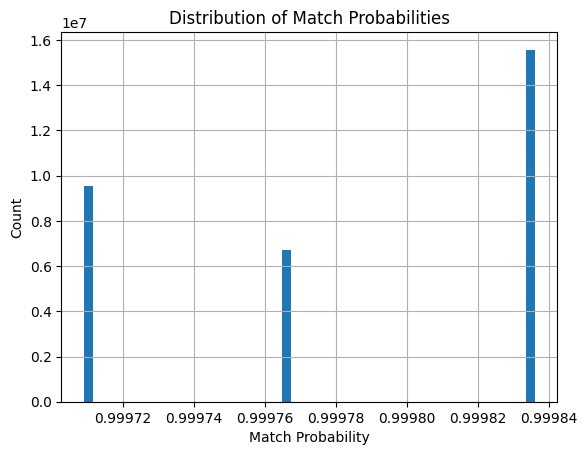

Exact same name matches: 15573349
Different name matches: 16246265

Sample of different name matches:
                       name_consolidated_l                     name_consolidated_r  match_probability
0                   LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
1                   LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
7                   LG Electronics USA Inc  LG Electronics MobileComm U.S.A., Inc.           0.999709
15                        John Does (1-10)                               John Does           0.999709
16                        John Does (1-10)                               John Does           0.999709
20                    LG Electronics, Inc.                  LG Electronics USA Inc           0.999709
21  LG Electronics MobileComm U.S.A., Inc.                  LG Electronics USA Inc           0.999709
22                    LG Electronics, Inc.                  LG Electronics USA Inc

In [29]:
# see distribution of match probabilities
import matplotlib.pyplot as plt

predictions_df['match_probability'].hist(bins=50)
plt.xlabel('Match Probability')
plt.ylabel('Count')
plt.title('Distribution of Match Probabilities')
plt.show()

# check how many are exact same name vs actually different
exact_same = predictions_df[
    predictions_df['name_consolidated_l'] == predictions_df['name_consolidated_r']
]
different_names = predictions_df[
    predictions_df['name_consolidated_l'] != predictions_df['name_consolidated_r']
]

print(f"Exact same name matches: {len(exact_same)}")
print(f"Different name matches: {len(different_names)}")
print(f"\nSample of different name matches:")
print(different_names[['name_consolidated_l', 'name_consolidated_r', 
                         'match_probability']].head(20).to_string())